# Refitting example

In [1]:
# --------------------------------------------------------
# Import packages
# --------------------------------------------------------
import jax.numpy as jnp
import matplotlib.pyplot as plt

from diffPLOG2TROE.kinetic_constants import FallOff, Plog
from diffPLOG2TROE.plog_refitter import PlogRefitter

## NH2 + H = NH3

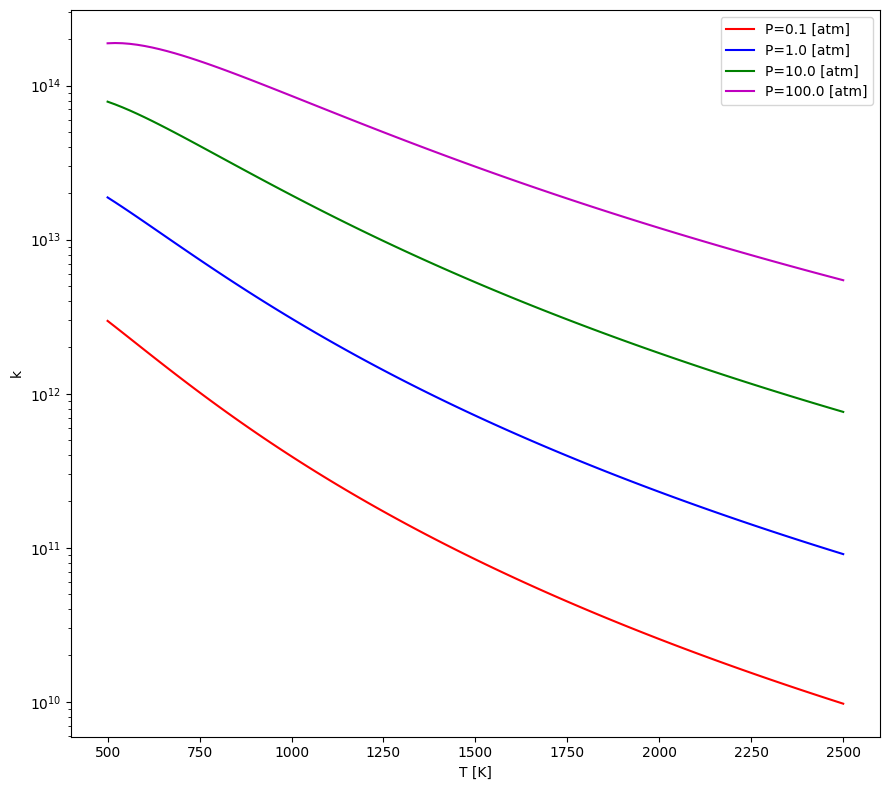

In [2]:
plog_dictionary = {
    "name": "NH2+H=NH3",
    "type": "plog",
    "rate-constant": {
        "coefficients": [
            [1.00000e-01, 1.21300e+27, -4.95900e+00, 2.80709e+03],
            [1.00000e+00, 5.86700e+27, -4.86700e+00, 3.10796e+03],
            [1.00000e+01, 3.31400e+28, -4.79800e+00, 3.83238e+03],
            [1.00000e+02, 4.51200e+28, -4.56300e+00, 4.72319e+03]
        ]
    }
}
starting_plog = Plog(plog_dictionary)

T_range = jnp.linspace(500, 2500, 100)
P_range = jnp.logspace(jnp.log10(0.1), jnp.log10(100), 100)
P_levels = jnp.array([0.1, 1, 10, 100])

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = starting_plog.kinetic_constant(T_range, P_levels)

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['r', 'b', 'g', 'm', 'k']

for i, ki_plog in enumerate(k_plog):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")

ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
fig.tight_layout()
plt.show()

Known that the high pressure limit for this reaction has been measured when we are going to refit its values into a TROE we are going to fix these values consistently

In [13]:
troe_param_config = {
    "A_high": {"optimize": False, "value": 1.50e+14},
    "n_high": {"optimize": False, "value": 0.167},
    "E_high": {"optimize": False, "value": 0.0},
}
refitter = PlogRefitter(
    plog_dict=plog_dictionary,
    T_range=(300, 2500),
    P_range=(0.1, 100),
    fitting_mode="single",
    primary_falloff_type="troe",
    param_config=troe_param_config,
    # log_name="OH_NO__OHNO-single.log"
)
results = refitter.optimize(
    max_iterations=1000,
    uncertainty_factor=0.8,
    uncertainty_type="symmetric",
    tol=1e-10
)


Plog to troe refitter
 Temperature range [K]: (300, 2500)
 Pressure range [atm]: (0.1, 100)
 Loss function: rmsle

Parameters configuration:
  A_low: optimizing from default initial value
  n_low: optimizing from default initial value
  E_low: optimizing from default initial value
  A_high: fixed at 1.50000e+14
  n_high: fixed at 1.67000e-01
  E_high: fixed at 0.00000e+00
  A: optimizing from default initial value
  T3: optimizing from default initial value
  T1: optimizing from default initial value
  T2: optimizing from default initial value

Estimating initial parameters:
Troe parameters
  High pressure limit (A, n, Ea): 1.500e+14, 0.167, 0.000e+00
  Low pressure limit (A, n, Ea): 9.954e+29, -3.959, 2.807e+03
  Troe parameters (A, T3, T1, T2): 0.500, 9.800e+02, 2.800e+02, 2.100e+03


Calculating optimization bounds (uncertainty factor: 0.8)

Bounds for Arrhenius parameters (high pressure limit):
  A_high: fixed at 3.264e+01
  n_high: fixed at 1.670e-01
  E_high: fixed at 0.000e+00



In [18]:
print(results["optimized_params"])

[ 7.12824727e+01 -4.19660643e+00  1.62217875e+03  6.04311049e-01
  2.79973099e+03  4.43770094e+01  6.82701961e+03]


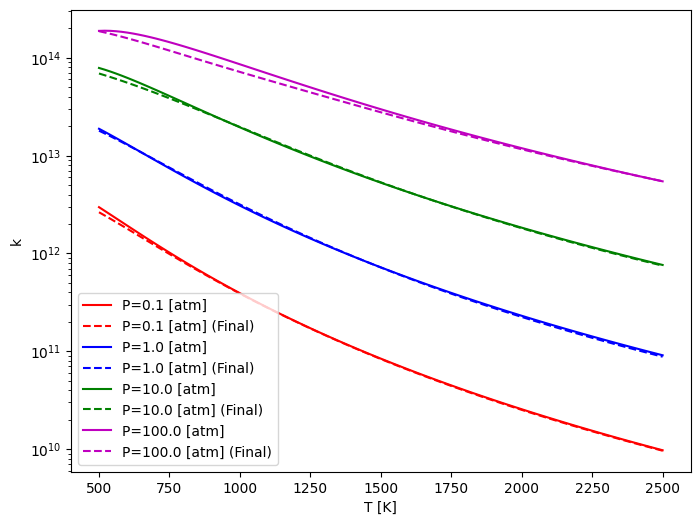

OH+NO(+M)=OHNO(+M)		1.50000e+14 0.16700 0.00000e+00
 LOW / 		9.06953e+30 -4.19661 3.22327e+03 /
 TROE / 6.04311e-01 2.79973e+03 4.43770e+01 6.82702e+03 /



In [19]:
params = results["optimized_params"]

troe = FallOff(
    name="OH+NO(+M)=OHNO(+M)",
    lpl_params=jnp.array([jnp.exp(params[0]), params[1], params[2]*1.987]),
    # hpl_params=jnp.array([jnp.exp(params[3]), params[4], params[5]*1.987]),
    hpl_params=jnp.array([1.50e+14, 0.167, 0.0]),
    falloff_params=jnp.array([params[3], params[4], params[5], params[6], params[7]]),
    falloff_type="troe"
)

# Let's start by computing the value of the kinetic constant and plotting it
k_plog = starting_plog.kinetic_constant(T_range, P_levels)
k_troe = troe.kinetic_constant(T_range, P_levels)[0]

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["r", "b", "g", "m", "c"]

for i, (ki_plog, ki_troe) in enumerate(zip(k_plog, k_troe)):
    ax.plot(T_range, ki_plog, '-', color=colors[i], label=f"P={P_levels[i]} [atm]")
    ax.plot(T_range, ki_troe, '--', color=colors[i], label=f"P={P_levels[i]} [atm] (Final)")
    
ax.set_yscale("log")
ax.set_xlabel("T [K]")
ax.set_ylabel("k")
ax.legend()
plt.show()

print(troe)

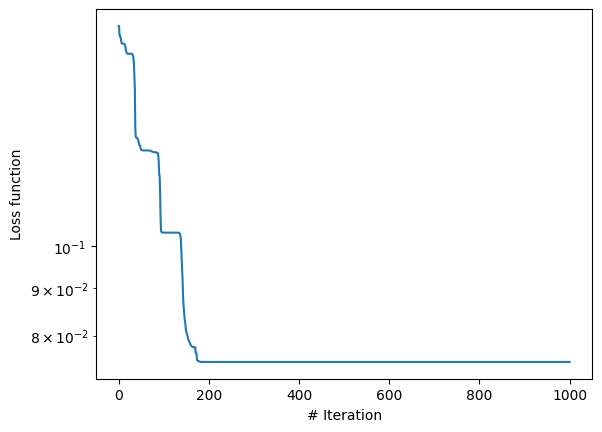

In [20]:
plt.semilogy(results["loss_history"])
plt.xlabel("# Iteration")
plt.ylabel("Loss function")
plt.show()

Minimum error: 0.8157546650167989
Maximum error: 1.0735076327684847
Average error: 0.02731704660485424


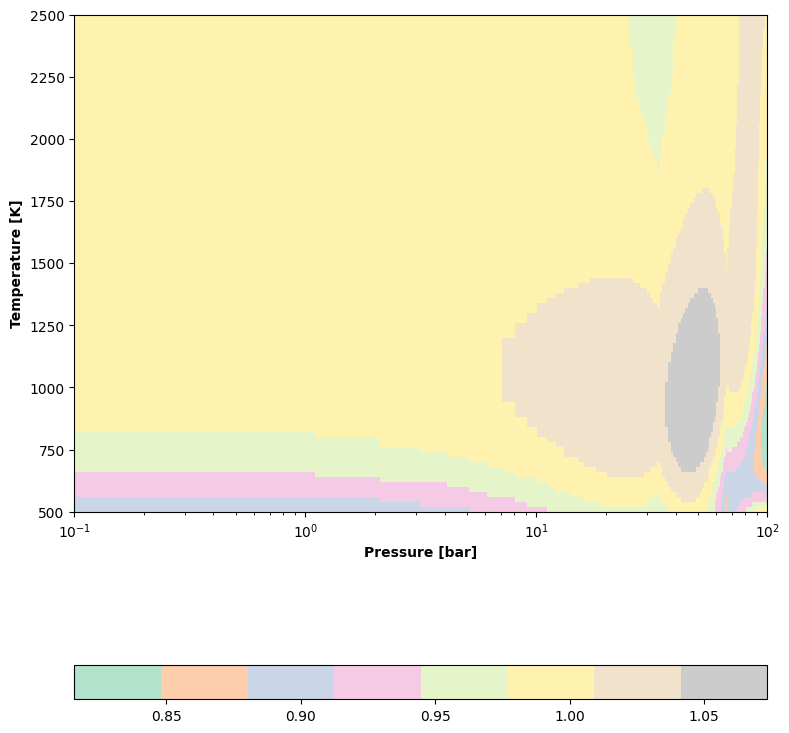

In [21]:
T_mesh, P_mesh = jnp.meshgrid(T_range, P_range)

k_plog = starting_plog.kinetic_constant(T_range, P_range)
k_troe = troe.kinetic_constant(T_range, P_range)[0]

ratio = k_troe.T / k_plog.T
rel_ratio = jnp.mean(jnp.sqrt((1 - k_troe.T / k_plog.T) ** 2))

plt.figure(figsize=(8, 8))
im = plt.imshow(
    ratio,
    origin="lower",
    aspect="auto",
    extent=[P_range[0], P_range[-1], T_range[0], T_range[-1]],
    cmap="Pastel2"
)
    
plt.xscale("log")
plt.xlabel("Pressure [bar]", fontweight="bold")
plt.ylabel("Temperature [K]", fontweight="bold")    
cbar = plt.colorbar(im, orientation="horizontal", pad=0.2)

print(f"Minimum error: {jnp.min(ratio)}")
print(f"Maximum error: {jnp.max(ratio)}")
print(f"Average error: {rel_ratio}")

plt.tight_layout()
plt.show()